## README:

This notebook performs qualitative diagnostics of the learning process by visualizing statistics accumulated during training.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv

In [3]:
load_dotenv(r'../.env')

DATA_DIR = os.getenv('DATA_DIR')

## Show all diagnostics

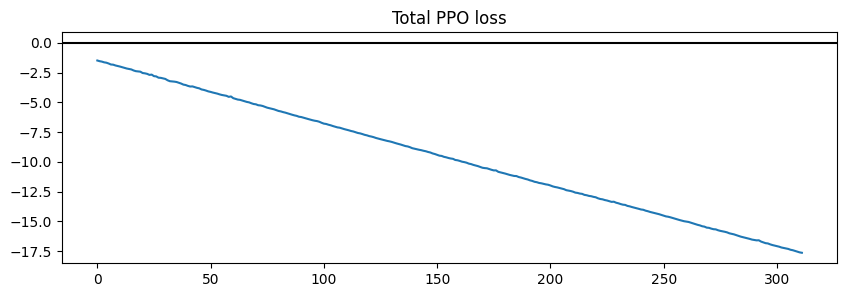

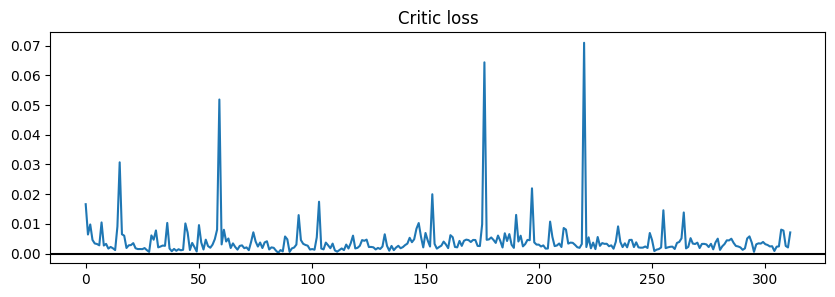

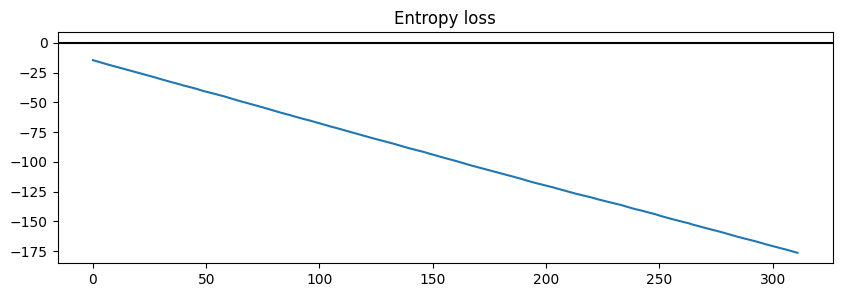

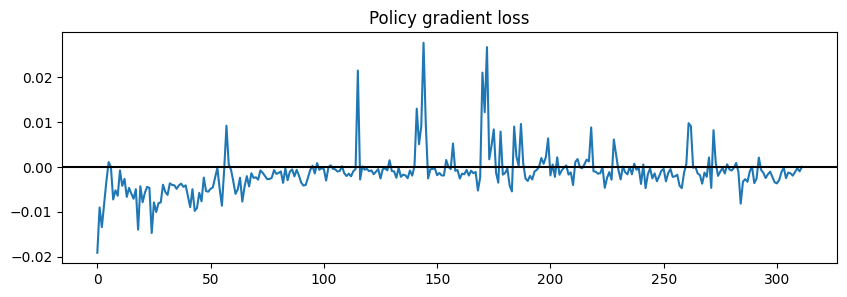

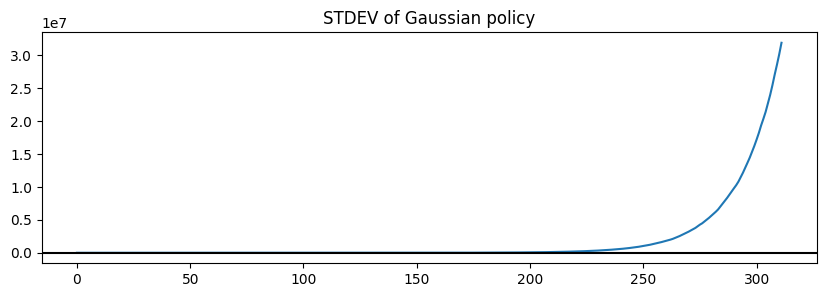

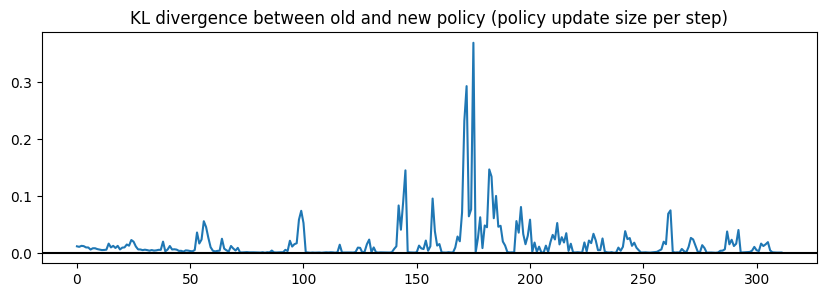

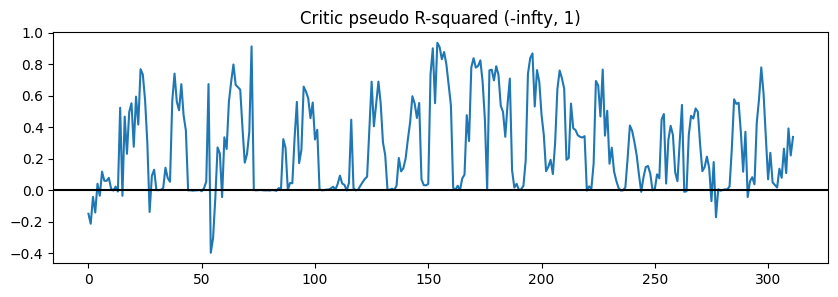

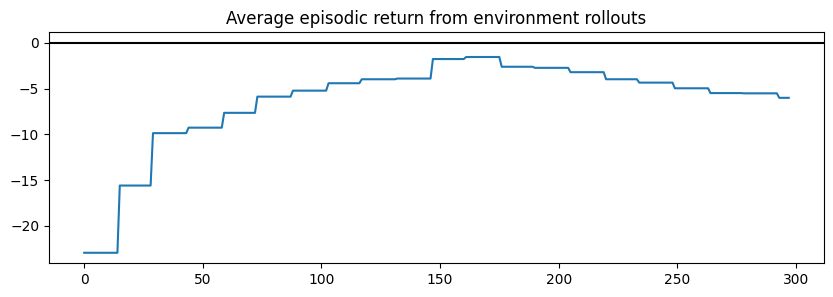

In [ ]:
run_name = 'mamba_ppo_20251214_2038_1' # MAMBA with penalized turnover (lambda=0.005)

file_names = [
    ('train__loss.csv', 'Total PPO loss'),
    ('train__value_loss.csv', 'Critic Value Function Loss (Mean Squared Error)'),
    ('train__entropy_loss.csv', 'Entropy loss'),
    ('train__policy_gradient_loss.csv', 'Policy gradient loss'),
    ('train__std.csv', 'Policy Action Distribution Standard Deviation'),
    ('train__approx_kl.csv', 'KL divergence between old and new policy (policy update size per step)'),
    ('train__explained_variance.csv', 'Explained Variance of the Value Function'),
    ('rollout__ep_rew_mean.csv', 'Mean Episodic Return'),
]

for filename, title in file_names:
    path = os.path.join(DATA_DIR, 'tensorboard_logs', run_name, 'csv_export', filename)
    df = pd.read_csv(path)

    fig, ax = plt.subplots(figsize=(10,3))
    ax.set_title(title)
    ax.plot(df['value'])
    ax.axhline(0, c='black')

In [ ]:
run_name = 'mamba_ppo_20251214_2038_1' # MAMBA with penalized turnover (lambda=0.005)

file_names = [
    ('train__loss.csv', 'Total PPO loss'),
    ('train__value_loss.csv', 'Critic loss'),
    ('train__entropy_loss.csv', 'Entropy loss'),
    ('train__policy_gradient_loss.csv', 'Policy gradient loss'),
    ('train__std.csv', 'STDEV of Gaussian policy'),
    ('train__approx_kl.csv', 'KL divergence between old and new policy (policy update size per step)'),
    ('train__explained_variance.csv', 'Critic pseudo R-squared (-infty, 1)'),
    ('rollout__ep_rew_mean.csv', 'Average episodic return from environment rollouts'),
]

for filename, title in file_names:
    path = os.path.join(DATA_DIR, 'tensorboard_logs', run_name, 'csv_export', filename)
    df = pd.read_csv(path)

    fig, ax = plt.subplots(figsize=(10,3))
    ax.set_title(title)
    ax.plot(df['value'])
    ax.axhline(0, c='black')

## Show key diagnostics

In [25]:
run_name = 'mamba_ppo_20251214_2038_1' # MAMBA with penalized turnover (lambda=0.005)

file_names = [
    ('train__value_loss.csv', 'Critic Value Function Loss (Mean Squared Error)'),
    ('train__explained_variance.csv', 'Explained Variance of the Value Function'),
    ('train__std.csv', 'Policy Action Distribution Standard Deviation'),
    ('rollout__ep_rew_mean.csv', 'Mean Episodic Return'),
]

x_series = None
x_series_list, y_series_list = [], []
titles = []
for filename, title in file_names:
    path = os.path.join(DATA_DIR, 'tensorboard_logs', run_name, 'csv_export', filename)
    df = pd.read_csv(path)
    y_series_list.append(df['value'])
    x_series_list.append(df['step'])
    titles.append(title)

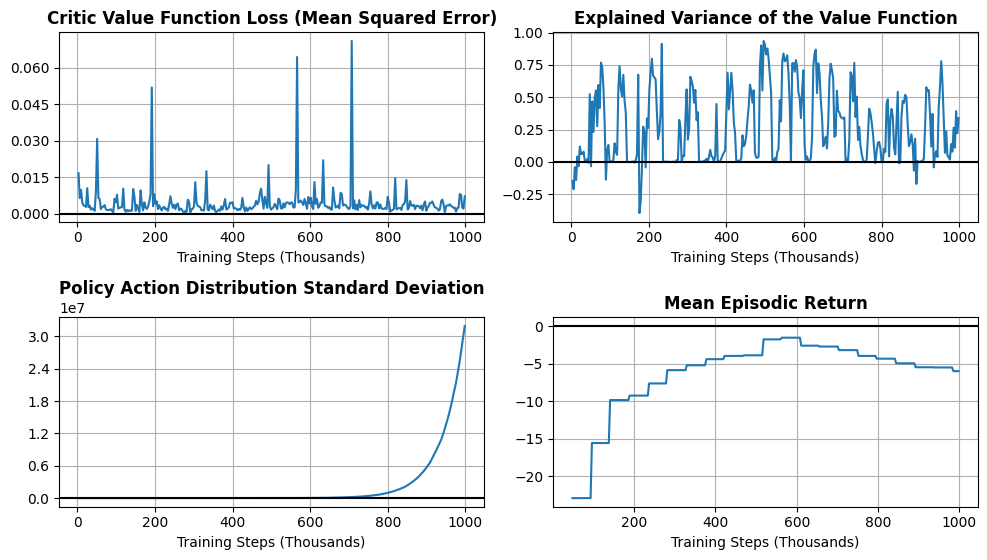

In [33]:
# show key diagnostics
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=False)
axes = axes.flatten()

# fig.suptitle("Diagnostics", fontsize=14)
for ax, x, y, title in zip(axes, x_series_list, y_series_list, titles):
    ax.plot(x.values, y.values)
    ax.axhline(0, c='black')
    ax.set_title(title, fontweight='bold')
    ax.grid(True)
    ax.xaxis.set_major_locator(plt.MultipleLocator(200_000))
    ax.xaxis.set_major_formatter(lambda x, _: f"{int(x/1000)}")
    ax.yaxis.set_major_locator(plt.MaxNLocator(6))
    ax.set_xlabel('Training Steps (Thousands)')

fig.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()
